Stratifying across 5 unique groups...
Success! Captured 210 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 160 GEOIDs for this split.


/tmp/ipykernel_2529/1169343827.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/tmp/ipykernel_2529/1169343827.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


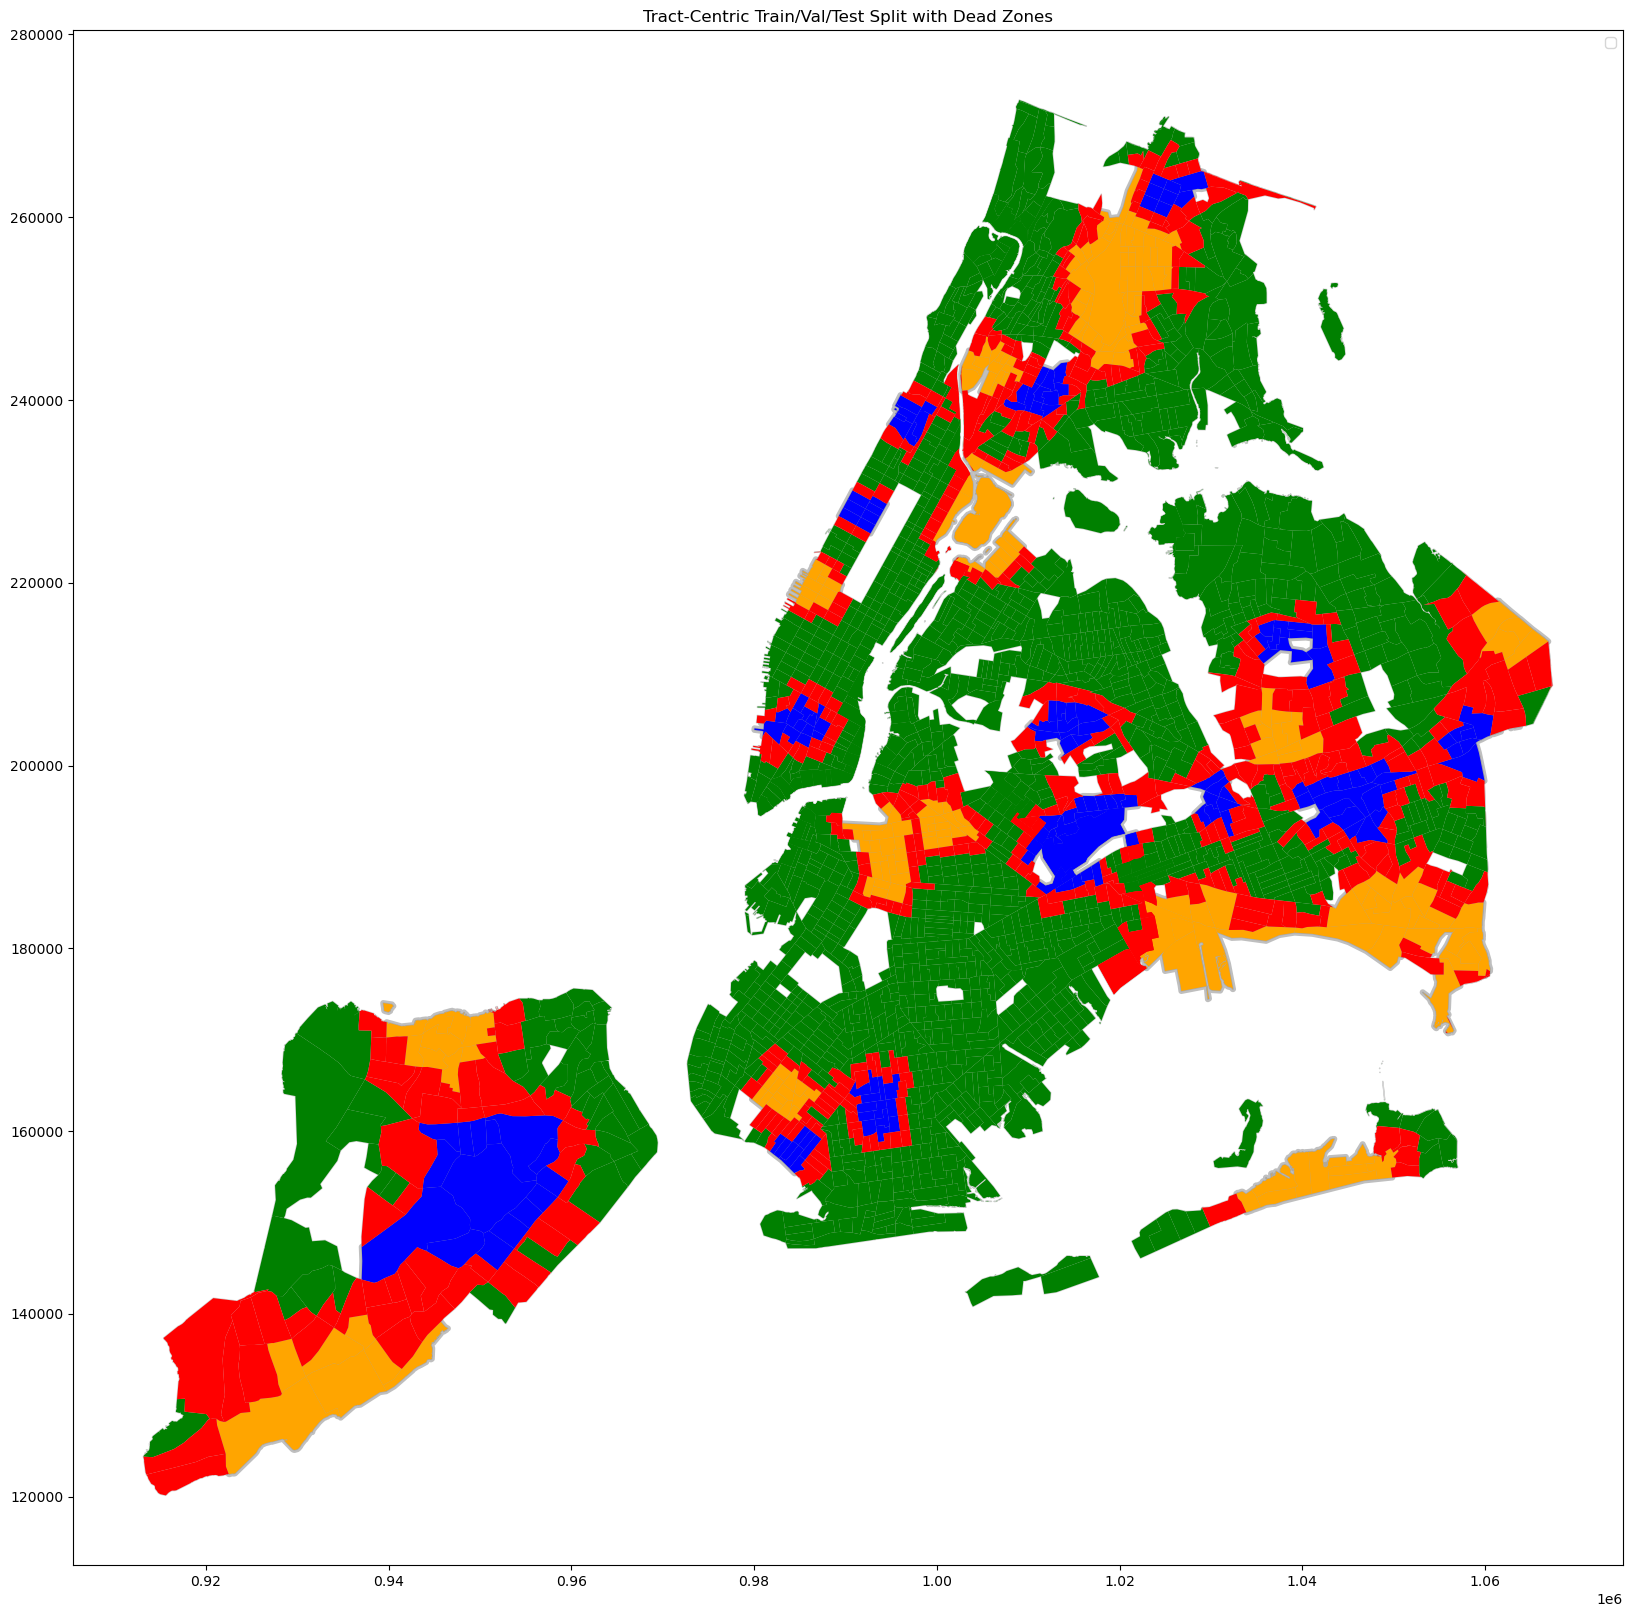

type
train        1476
dead_zone     488
test          215
val           166
Name: count, dtype: int64
Reading dataset...
Output files already exist at:
  /mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/temporal_data_t100_years2010-2024.parquet
  /mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/building_geometries_years2010-2024.parquet
Loading existing datasets...
Loaded datasets for years [2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]: ['nyc_2010.zarr', 'nyc_2012.zarr', 'nyc_2014.zarr', 'nyc_2016.zarr', 'nyc_2018.zarr', 'nyc_2020.zarr', 'nyc_2022.zarr', 'nyc_2024.zarr']
Buildings without images): 124228 out of 8661640
Buildings for datasets (train/test/val): 8537412
Datasets loaded!


KeyError: 'index_right'

In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from src.utils import paths
from src import geo_utils
from shapely.geometry import box

gdf = gpd.read_feather(paths.PROCESSED_DATA_DIR / "ny_tracts_panel_2009_2014_2019_2024.feather").to_crs(epsg=6539).rename(columns={"geoid_2024": "GEOID"})
boros = gpd.read_file(paths.EXTERNAL_DATA_DIR / "NYC Borough Boundaries" / "Borough_Boundaries_20260131.geojson").to_crs(epsg=6539)

# Add quintiles and boroname to gdf for later tabulation of test area coverage by borough and income quintile
gdf = gdf.sjoin(boros[["boroname", "geometry"]], how="left", predicate="intersects").drop(columns=["index_right"])
gdf["income_quintile"] = pd.qcut(gdf["Rel_Score_2024"], q=5, labels=False)
gdf = gdf.dropna(subset=["income_quintile"]).reset_index(drop=True)

def create_stratified_tract_holdout(gdf, cluster_radius, stratify_cols, eval_fraction=0.05, exclude_mask=None):
    """
    Creates a holdout set by growing contiguous clusters of tracts.
    Uses a spatial exclude_mask to ensure clusters do not cross into restricted territories.
    """
    captured_geoids = set()
    holdout_indices = []

    # Drop any tracts that fall into the restricted exclusion zone
    if exclude_mask is not None:
        available_gdf = gdf[~exclude_mask].copy()
    else:
        available_gdf = gdf.copy()
        
    groups = available_gdf.groupby(stratify_cols, dropna=False)
    
    print(f"Stratifying across {len(groups)} unique groups...")

    for name, group in groups:
        unique_group_geoids = set(group['GEOID'].unique())
        target_count = math.ceil(len(unique_group_geoids) * eval_fraction)
        
        if target_count == 0: continue
            
        group_captured = len(unique_group_geoids.intersection(captured_geoids))
        
        while group_captured < target_count:
            # 1. Sample a random seed tract from this group
            areas = group.geometry.area
            if areas.sum() == 0: break
            
            # np.random.choice uses the global numpy random seed
            seed_idx = np.random.choice(group.index, p=areas / areas.sum())
            seed_geom = group.loc[seed_idx].geometry
            
            # 2. Capture all tracts within the radius to form a contiguous cluster
            cluster_mask = available_gdf.geometry.intersects(seed_geom.buffer(cluster_radius))
            cluster_tracts = available_gdf[cluster_mask]
            
            if cluster_tracts.empty: continue
            
            # 3. Update tracking variables
            current_geoids = set(cluster_tracts['GEOID'].unique())
            captured_geoids.update(current_geoids)
            holdout_indices.extend(cluster_tracts.index.tolist())
            
            group_captured = len(unique_group_geoids.intersection(captured_geoids))
            
    print(f"Success! Captured {len(captured_geoids)} GEOIDs for this split.")
    
    # SORT the list so that Python's hash randomization doesn't alter the output row order
    deterministic_indices = sorted(list(set(holdout_indices)))
    return gdf.loc[deterministic_indices].copy()

def assign_tracts_train_val_test(gdf, test_tracts, val_tracts, dead_zone_buffer):
    """
    Assigns the final splits and calculates the exact dead zone needed to prevent spatial leakage.
    """
    gdf['type'] = 'train' # Default to train
    
    # 1. Combine all holdout tracts to calculate a unified dead zone
    holdouts = pd.concat([test_tracts, val_tracts])
    
    # 2. Buffer the exact, irregular boundaries of the holdout tracts by tau
    dead_zone_geom = holdouts.geometry.union_all().buffer(dead_zone_buffer)
    
    # 3. Find any tract that touches this buffer
    in_dead_zone = gdf.geometry.intersects(dead_zone_geom)
    
    # 4. Apply assignment hierarchy (Holdouts override Dead Zone override Train)
    gdf.loc[in_dead_zone, 'type'] = 'dead_zone'
    
    if not val_tracts.empty:
        gdf.loc[gdf.index.isin(val_tracts.index), 'type'] = 'val'
    if not test_tracts.empty:
        gdf.loc[gdf.index.isin(test_tracts.index), 'type'] = 'test'
        
    return gdf, gpd.GeoDataFrame(geometry=[dead_zone_geom], crs=gdf.crs)

def plot_final_splits(gdf, dead_zone_gdf):
    ax = gdf.plot(figsize=(20, 20), color='whitesmoke', edgecolor='lightgray')
    dead_zone_gdf.plot(ax=ax, color="gray", alpha=0.5, label="Dead Zone (Buffer)")
    
    gdf[gdf["type"] == "train"].plot(ax=ax, color="green", label="Train")
    gdf[gdf["type"] == "val"].plot(ax=ax, color="blue", label="Validation")
    gdf[gdf["type"] == "test"].plot(ax=ax, color="orange", label="Test")
    gdf[gdf["type"] == "dead_zone"].plot(ax=ax, color="red", label="Dead Zone (Discarded Tracts)")
    
    plt.legend()
    plt.title("Tract-Centric Train/Val/Test Split with Dead Zones")
    plt.show()

    print(gdf['type'].value_counts())


# ==========================================
# EXECUTION BLOCK
# ==========================================

# 0. SET RANDOM SEED FOR REPRODUCIBILITY
RANDOM_SEED = 25
np.random.seed(RANDOM_SEED)

# --- Parameters ---
cluster_radius = geo_utils.meters_to_projected_units(300, epsg_code=6539) 
dead_zone_buffer = geo_utils.meters_to_projected_units(100, epsg_code=6539) # Your tau parameter

# 1. Generate TEST Holdout (5%)
test_tracts = create_stratified_tract_holdout(
    gdf, 
    cluster_radius=cluster_radius, 
    stratify_cols=["income_quintile"], 
    eval_fraction=0.06
)

# 2. CREATE A STRICT QUARANTINE ZONE AROUND THE TEST SET
test_restricted_geom = test_tracts.geometry.union_all().buffer(dead_zone_buffer)
invalid_val_candidates_mask = gdf.geometry.intersects(test_restricted_geom)

# 3. Generate VALIDATION Holdout (5%) 
val_tracts = create_stratified_tract_holdout(
    gdf, 
    cluster_radius=cluster_radius, 
    stratify_cols=["income_quintile"], 
    eval_fraction=0.06, 
    exclude_mask=invalid_val_candidates_mask
)

# 4. Assign labels and compute the final combined dead zones for the Train set
gdf, dead_zone_geom_gdf = assign_tracts_train_val_test(
    gdf, 
    test_tracts, 
    val_tracts, 
    dead_zone_buffer
)

# --- Plot and Verify ---
plot_final_splits(gdf, dead_zone_geom_gdf)

from src.utils.paths import PROCESSED_DATA_DIR 
gdf[["GEOID", "geometry", "type"]].to_feather(PROCESSED_DATA_DIR / "tract_splits.feather", index=False)


import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
from typing import List, Tuple

from src import build_dataset
from src.main import open_datasets


import importlib

importlib.reload(build_dataset)

sat_data = "aerial"
years= [2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]
tau_meters = 100

all_years_datasets, all_years_extents, df = open_datasets(
    sat_data=sat_data, years=years, tau_meters=tau_meters
)

NameError: name 'df' is not defined

In [2]:
from src.build_dataset import process_acs_panel

df = process_acs_panel()

Loading and processing ACS panel data...


In [11]:
gdf_buildings = gpd.GeoDataFrame(
    df[["GEOID", "centroid_x", "centroid_y"]],
    geometry=gpd.points_from_xy(df["centroid_x"], df["centroid_y"]),
    crs="EPSG:6539"
)
gdf_buildings.loc[final_train_mask, 'split'] = 'train'
gdf_buildings.loc[final_test_mask, 'split'] = 'test'
gdf_buildings.loc[final_val_mask, 'split'] = 'val'
gdf_buildings['split'] = gdf_buildings['split'].fillna('dropped')
gdf_buildings.to_feather(PROCESSED_DATA_DIR / "building_splits.feather", index=False)

In [ ]:
gdf_buildings = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['centroid_x'], df['centroid_y']), crs="EPSG:6539")

gdf_buildings.loc[final_train_mask, 'split'] = 'train'
gdf_buildings.loc[final_test_mask, 'split'] = 'test'
gdf_buildings.loc[final_val_mask, 'split'] = 'val'
gdf_buildings['split'] = gdf_buildings['split'].fillna('dropped')
# Plotting
fig, ax = plt.subplots(figsize=(12, 12))
gdf_buildings.plot(ax=ax, column='split', categorical=True, legend=True, markersize=1)
plt.title("Building Splits Visualization")
plt.show()

In [ ]:
import src.geo_utils as geo_utils

total_train_k = []
total_test_k = []
total_val_k = []
total_dead_zone_k = []

k_min = 200
k_max = 2600
step = 200
for k in range(k_min, k_max, step):

    train_k = []
    test_k = []
    val_k = []
    dead_zone_k = []

    for _ in range(20):  # Run multiple iterations for each k to get an average
        cluster_radius = geo_utils.meters_to_projected_units(k, epsg_code=6539) 
        dead_zone_buffer = geo_utils.meters_to_projected_units(150, epsg_code=6539) # Your tau parameter

        # 1. Generate TEST Holdout (5%)
        test_tracts = create_stratified_tract_holdout(
            gdf, 
            cluster_radius=cluster_radius, 
            stratify_cols=["income_quintile"], 
            eval_fraction=0.05
        )

        # 2. CREATE A STRICT QUARANTINE ZONE AROUND THE TEST SET
        # We buffer the test tracts by your tau parameter to prevent Val from getting close
        test_restricted_geom = test_tracts.geometry.union_all().buffer(dead_zone_buffer)
        invalid_val_candidates_mask = gdf.geometry.intersects(test_restricted_geom)

        # 3. Generate VALIDATION Holdout (10%) 
        # Pass the exclusion mask so Val clusters physically cannot touch the Test clusters
        val_tracts = create_stratified_tract_holdout(
            gdf, 
            cluster_radius=cluster_radius, 
            stratify_cols=["income_quintile"], 
            eval_fraction=0.10, 
            exclude_mask=invalid_val_candidates_mask # <-- The fix is applied here
        )

        # 4. Assign labels and compute the final combined dead zones for the Train set
        gdf, dead_zone_geom_gdf = assign_train_val_test_splits(
            gdf, 
            test_tracts, 
            val_tracts, 
            dead_zone_buffer
        )

        train_k.append((gdf['type'] == 'train').sum())
        test_k.append((gdf['type'] == 'test').sum())
        val_k.append((gdf['type'] == 'val').sum())
        dead_zone_k.append((gdf['type'] == 'dead_zone').sum())

    total_train_k.append(np.mean(train_k))
    total_test_k.append(np.mean(test_k))
    total_dead_zone_k.append(np.mean(dead_zone_k))
    total_val_k.append(np.mean(val_k))

import matplotlib.pyplot as plt
ks = list(range(k_min, k_max, step))
plt.plot(ks, total_train_k, label="Train")
plt.plot(ks, total_test_k, label="Test")
plt.plot(ks, total_dead_zone_k, label="Dead Zone")
plt.plot(ks, total_val_k, label="Validation")
plt.xlabel("k (half-side of square in meters)")
plt.ylabel("Number of Polygons")
plt.title("Dataset Size by k")
plt.legend()

Stratifying across 5 unique groups...
Success! Captured 161 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 245 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 181 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 247 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 137 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 233 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 156 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 254 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 170 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 268 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 191 GEOIDs for this split.
Stratifying across 5 unique groups...
Success! Captured 254 GEOIDs for this split.
Stra

KeyboardInterrupt: 

In [ ]:
import warnings

import shapely
import numpy as np
import pandas as pd
import geopandas as gpd
from typing import List, Tuple


from src import build_dataset
from src.main import open_datasets

def split_train_test(
    df: pd.DataFrame, 
    val_polygon: shapely.geometry.Polygon = None,
    test_polygon: shapely.geometry.Polygon = None,
    test_years: List[int] = None,
    test_column: str = "None",
    jitter_buffer: float = 0.0
) -> Tuple[pd.Series, pd.Series, pd.Series]:
    """
    Splits a flat dataset into train and test sets using pure numerical bounding box comparisons
    against multiple test patches (extracted from the split GDF).
    """
    if test_years is None:
        test_years = []

    ###############################
    ##### SPATIAL SPLIT LOGIC #####
    ###############################

    # Pre-extract building arrays with Jitter Buffer applied to BBOX
    jitter_buffer_crs = geo_utils.meters_to_projected_units(jitter_buffer, epsg_code=6539)
    b_minx = df['bbox_minx'].values - jitter_buffer_crs
    b_miny = df['bbox_miny'].values - jitter_buffer_crs
    b_maxx = df['bbox_maxx'].values + jitter_buffer_crs
    b_maxy = df['bbox_maxy'].values + jitter_buffer_crs
    bboxes = gpd.GeoSeries(
        shapely.box(b_minx, b_miny, b_maxx, b_maxy), 
        crs="EPSG:6539",
        index=df.index
    )
    
    # Generate centroid arrays for point-in-polygon checks
    centroids = gpd.GeoSeries(
        gpd.points_from_xy(df['centroid_x'], df['centroid_y']), 
        crs="EPSG:6539", 
        index=df.index
    )

    # Initialize boolean masks as NumPy arrays (default False)
    spatial_test_mask = np.zeros(len(df), dtype=bool)
    spatial_val_mask = np.zeros(len(df), dtype=bool)
    train_drop_mask = np.zeros(len(df), dtype=bool) 
    

    ## Assigment logic:
    # - If a building falls entirely inside ANY test/val patch, assign it to that set
    # - If a building's BBOX expanded by jitter_buffer intersects ANY test/val patch, drop it from train
    
    # Assign to test/val based on centroids first (strict point-in-polygon)
    if test_polygon is not None:
        spatial_test_mask = centroids.within(test_polygon)
    if val_polygon is not None:
        spatial_val_mask = centroids.within(val_polygon)
    
    # Remove any building that whose image intersects with test/val from the train drop mask consideration
    if test_polygon is not None:
        train_drop_mask |= bboxes.intersects(test_polygon)
    if val_polygon is not None:
        train_drop_mask |= bboxes.intersects(val_polygon)

    ###############################    
    #####   TIME SPLIT LOGIC  #####
    ###############################

    time_mask_np = np.zeros(len(df), dtype=bool)
    for test_year in test_years:
        time_mask_np |= (df["year"].values == test_year)

    ###############################
    #####  OTHER SPLIT LOGIC  #####
    ###############################

    other_mask_np = np.zeros(len(df), dtype=bool)
    if test_column in df.columns:
        other_mask_np = (df[test_column].values == True)

    ###################################
    ##### FINAL COMBINATION LOGIC #####
    ###################################
    final_test_mask_np = spatial_test_mask | time_mask_np | other_mask_np

    # The removal of val candidates that overlap with test ensures val is strictly quarantined 
    #   from test, even in edge cases where jitter causes train drops to overlap with test/val.
    #   I dont think this is strictly necessary, but it provides an extra layer of safety to ensure 
    #   no val building is even remotely close to test buildings.
    final_val_mask_np = spatial_val_mask & ~final_test_mask_np  

    # Train set is everything NOT inside test, val, or the dropped expansion zones
    final_train_mask_np = (~train_drop_mask) & (~final_test_mask_np) & (~final_val_mask_np)


    # Convert back to Pandas Series with original index
    final_train_mask = pd.Series(final_train_mask_np, index=df.index)
    final_test_mask = pd.Series(final_test_mask_np, index=df.index)
    final_val_mask = pd.Series(final_val_mask_np, index=df.index)
    
    train_tracts = df[final_train_mask].drop_duplicates("GEOID").shape[0]
    test_tracts = df[final_test_mask].drop_duplicates("GEOID").shape[0]
    val_tracts = df[final_val_mask].drop_duplicates("GEOID").shape[0]

    # Logging
    print(f"Total buildings evaluated: {len(df):,}")
    print(f"Assigned to Test Set (strictly inside patches/criteria): {final_test_mask.sum():,} ({test_tracts.sum():,} tracts)")
    print(f"     - of which assigned by spatial split: {spatial_test_mask.sum():,}")
    print(f"     - of which assigned by temporal split: {time_mask_np.sum():,}")
    print(f"     - of which assigned by other split ({test_column}): {other_mask_np.sum():,}")
    
    overlaps = (spatial_test_mask & time_mask_np).sum() + (spatial_test_mask & other_mask_np).sum() + (time_mask_np & other_mask_np).sum()
    print(f"     - Overlaps between criteria: {overlaps:,}")
    
    print(f"Assigned to Validation Set: {final_val_mask.sum():,} ({val_tracts.sum():,} tracts)")
    print(f"Assigned to Train Set: {final_train_mask.sum():,} ({train_tracts.sum():,} tracts)")
    
    dropped = len(df) - final_test_mask.sum() - final_val_mask.sum() - final_train_mask.sum()
    print(f"Dropped (spatial moat/buffer zone): {dropped:,}")

    return final_train_mask, final_test_mask, final_val_mask

import importlib

importlib.reload(build_dataset)

sat_data = "aerial"
years= [2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]
tau_meters = 100

all_years_datasets, all_years_extents, df = open_datasets(
    sat_data=sat_data, years=years, tau_meters=tau_meters
)
test_polygon = assigned_tracts[assigned_tracts["type"] == "test"].union_all()
val_polygon = assigned_tracts[assigned_tracts["type"] == "val"].union_all()

assigned_tracts = gpd.read_feather(PROCESSED_DATA_DIR / "tract_splits.feather").set_index("GEOID")
final_train_mask, final_test_mask, final_val_mask = split_train_test(
    df, 
    val_polygon,
    test_polygon,
    test_years=[2016],
    test_column=None,
    jitter_buffer=10.0
)

Reading dataset...
Output files already exist at:
  /mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/temporal_data_t100_years2010-2024.parquet
  /mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/building_geometries_years2010-2024.parquet
Loading existing datasets...
Loaded datasets for years [2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]: ['nyc_2010.zarr', 'nyc_2012.zarr', 'nyc_2014.zarr', 'nyc_2016.zarr', 'nyc_2018.zarr', 'nyc_2020.zarr', 'nyc_2022.zarr', 'nyc_2024.zarr']
Buildings without images): 124228 out of 8661640
Buildings for datasets (train/test/val): 8537412
Datasets loaded!


In [43]:
df

,DOITT_ID,GEOID,year,bbox_minx,bbox_miny,bbox_maxx,bbox_maxy,centroid_x,centroid_y,Rel_Score,Valid_Structural_Change,score_bin,dataset,row_start,row_stop,col_start,col_stop
0,753400,36047050700,2010,9.987683e+05,194507.772868,9.994245e+05,195163.939535,9.990964e+05,194835.856201,-2.669892,True,0,nyc_2010.zarr,164672.0,165985.0,182537.0,183849.0
1,684953,36005039100,2010,1.014509e+06,249525.486505,1.015165e+06,250181.653172,1.014837e+06,249853.569839,-1.490254,True,0,nyc_2010.zarr,54637.0,55949.0,214017.0,215330.0
2,1238079,36081157102,2010,1.060462e+06,206079.757568,1.061118e+06,206735.924234,1.060790e+06,206407.840901,-0.253457,False,3,nyc_2010.zarr,141528.0,142841.0,305924.0,307237.0
3,51599,36005028100,2010,1.014212e+06,260627.124594,1.014868e+06,261283.291260,1.014540e+06,260955.207927,0.399895,True,7,nyc_2010.zarr,32433.0,33746.0,213424.0,214736.0
4,773552,36081107201,2010,1.033783e+06,162047.646191,1.034439e+06,162703.812858,1.034111e+06,162375.729525,0.497452,False,7,nyc_2010.zarr,229592.0,230905.0,252566.0,253878.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8661635,1305559,36081008300,2024,1.003888e+06,220183.220827,1.004544e+06,220839.387493,1.004216e+06,220511.304160,0.392937,True,7,nyc_2024.zarr,113321.0,114633.0,87776.0,89089.0
8661636,1305594,36005040501,2024,1.014216e+06,255279.639323,1.014872e+06,255935.805990,1.014544e+06,255607.722656,-1.023804,False,0,nyc_2024.zarr,43128.0,44441.0,108433.0,109745.0
8661637,1305593,36005040502,2024,1.014592e+06,254906.458740,1.015248e+06,255562.625407,1.014920e+06,255234.542073,-1.047751,False,0,nyc_2024.zarr,43875.0,45187.0,109184.0,110496.0
8661638,1305575,36005040800,2024,1.022171e+06,263318.823889,1.022827e+06,263974.990556,1.022499e+06,263646.907223,-0.951310,False,0,nyc_2024.zarr,27050.0,28362.0,124341.0,125654.0


In [41]:
gdf_buildings = gpd.GeoDataFrame(
    df[["DOITT_ID", "year", "centroid_x", "centroid_y"]],
    geometry=gpd.points_from_xy(df["centroid_x"], df["centroid_y"]),
    crs="EPSG:6539"
)
gdf_buildings.loc[final_train_mask, 'split'] = 'train'
gdf_buildings.loc[final_test_mask, 'split'] = 'test'
gdf_buildings.loc[final_val_mask, 'split'] = 'val'
gdf_buildings['split'] = gdf_buildings['split'].fillna('dropped')
gdf_buildings.to_feather(PROCESSED_DATA_DIR / "building_splits.feather", index=False)

In [33]:
from src.utils.paths import PROCESSED_DATA_DIR
gdf_buildings[['geometry','split']].to_feather(PROCESSED_DATA_DIR / "building_splits.feather", index=False)

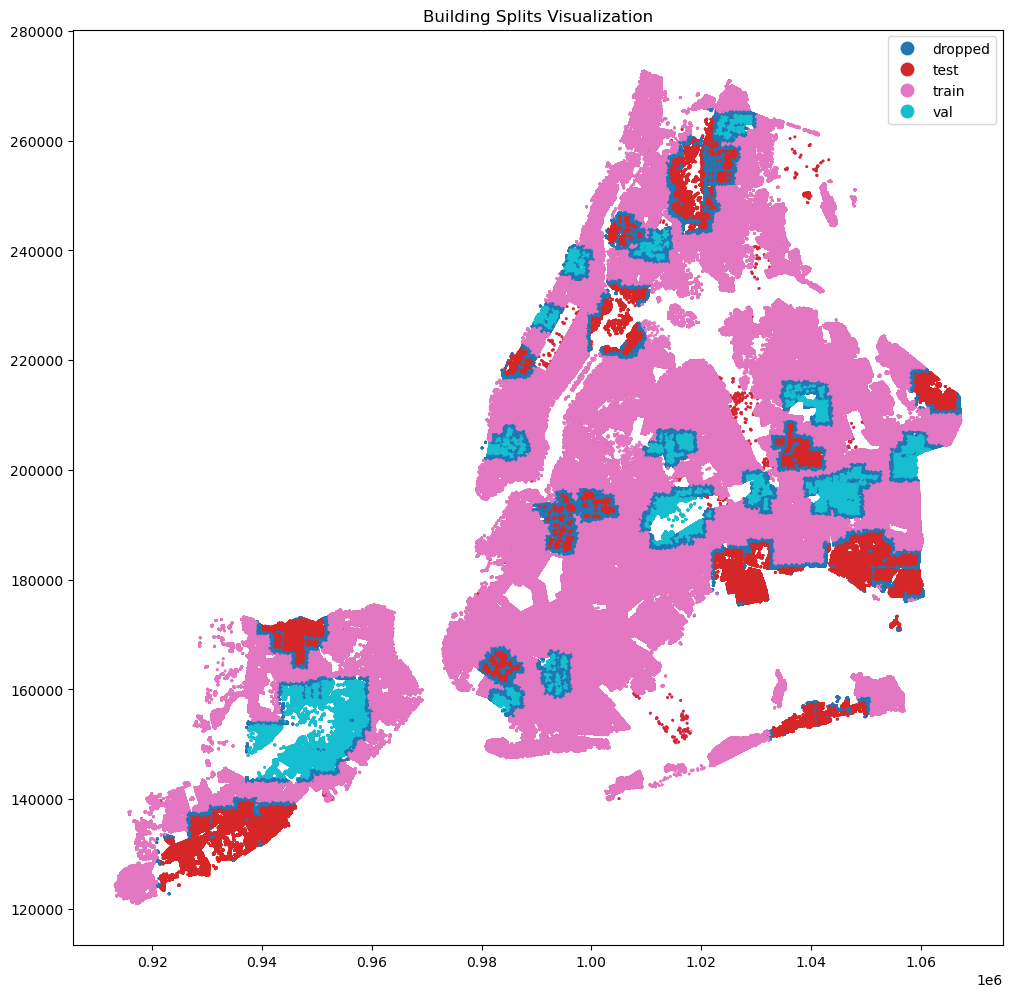

In [30]:
gdf_buildings.loc[final_train_mask, 'split'] = 'train'
gdf_buildings.loc[final_test_mask, 'split'] = 'test'
gdf_buildings.loc[final_val_mask, 'split'] = 'val'
gdf_buildings['split'] = gdf_buildings['split'].fillna('dropped')
# Plotting
fig, ax = plt.subplots(figsize=(12, 12))
gdf_buildings.plot(ax=ax, column='split', categorical=True, legend=True, markersize=1)
plt.title("Building Splits Visualization")
plt.show()

In [6]:
gdf = gpd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/ny_tracts_panel_2009_2014_2019_2024.feather").to_crs(epsg=6539)
gdf = gdf.rename(columns={"geoid_2024": "GEOID"})
# split_train_test(
#     df, 
#     gdf, 
#     test_years=[2016],
#     test_column=None,
#     jitter_buffer=10.0
# )

In [7]:
final_train_mask, final_test_mask, final_val_mask = split_train_test(
    df, 
    gdf, 
    test_years=[2016],
    test_column=None,
    jitter_buffer=10.0
)

Total buildings evaluated: 8,537,412
Assigned to Test Set (strictly inside patches/criteria): 1,082,136
     - of which assigned by spatial split: 0
     - of which assigned by temporal split: 1,082,136
     - of which assigned by other split (None): 0
     - Overlaps between criteria: 0
Assigned to Validation Set (strictly inside val patches): 0
Assigned to Train Set (strictly outside patches + buffer): 7,455,276
Dropped (spatial moat/buffer zone): 0


In [ ]:
df[final_train_mask].sample(n=100)  #, final_test_mask, final_val_mask]

,DOITT_ID,GEOID,year,bbox_minx,bbox_miny,bbox_maxx,bbox_maxy,centroid_x,centroid_y,Rel_Score,Valid_Structural_Change,score_bin,dataset,row_start,row_stop,col_start,col_stop
4489907,1227765,36085013800,2018,9.485463e+05,147716.195031,9.492025e+05,148372.361698,9.488744e+05,148044.278364,0.575396,False,8,nyc_2022.zarr,258255.0,259568.0,82093.0,83405.0
5055840,619268,36085012804,2018,9.553590e+05,144066.386037,9.560152e+05,144722.552703,9.556871e+05,144394.469370,0.290322,False,6,nyc_2022.zarr,265555.0,266867.0,95718.0,97031.0
5040382,248026,36081157903,2018,1.065631e+06,206290.814618,1.066287e+06,206946.981285,1.065959e+06,206618.897951,-0.206393,True,3,nyc_2024.zarr,141106.0,142418.0,211263.0,212575.0
8361360,296349,36081011300,2024,1.008947e+06,221749.060896,1.009603e+06,222405.227563,1.009275e+06,222077.144229,0.413741,False,7,nyc_2024.zarr,110189.0,111502.0,97894.0,99206.0
5478866,1278075,36081152902,2020,1.060369e+06,214925.566694,1.061026e+06,215581.733360,1.060698e+06,215253.650027,0.362853,False,7,nyc_2024.zarr,123837.0,125149.0,200739.0,202051.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2449954,147497,36061004001,2014,9.879788e+05,204677.473373,9.886350e+05,205333.640040,9.883069e+05,205005.556707,1.350997,False,9,nyc_2024.zarr,144333.0,145645.0,55958.0,57270.0
4814606,31834,36085020803,2018,9.266068e+05,133172.540831,9.272629e+05,133828.707497,9.269348e+05,133500.624164,0.535087,False,8,nyc_2022.zarr,287343.0,288655.0,38213.0,39526.0
8472803,889413,36047077600,2024,1.000264e+06,168656.851712,1.000920e+06,169313.018379,1.000592e+06,168984.935045,0.116895,False,6,nyc_2024.zarr,216374.0,217686.0,80529.0,81841.0
2022706,357345,36085013800,2012,9.477553e+05,147306.062850,9.484115e+05,147962.229517,9.480834e+05,147634.146183,0.651112,False,8,nyc_2022.zarr,259075.0,260388.0,80511.0,81823.0
